# Set Covering Problem — Constructive Heuristics and Iterative Improvement
### Exercise 1.1 / 1.2 — CH1, CH2, CH3, redundancy elimination, FI and BI local search

This notebook builds three constructive heuristics (CH1 random, CH2 greedy cost/gain, CH3 regret), applies redundancy elimination (RE), and then implements two iterative improvement algorithms — first-improvement (FI) and best-improvement (BI) — for the SCP.

### The notebook covers:
1. Instance reading, incremental solution state and best-known solutions (BKS).
2. Constructive heuristics CH1, CH2, CH3 and RE (CH1+RE is RE applied to the CH1 solution).
3. Two local-search neighborhoods: **1-1 swap + RE** and **remove one set + greedy repair + RE**; FI and BI for each.
4. 16 experiments per instance (4 starting solutions × FI/BI × 2 neighborhoods). The 8 required ones use the swap neighborhood.
5. Results: average % deviation from BKS, total computation time, fraction of instances improved by local search, plots and interpretation.

## 1. Imports and configuration

`DATA_DIR` is relative to the notebook's current working directory. The data is in the `SCP-Instances/`, in the same directory.

In [12]:
import heapq
import random
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.container import BarContainer

from scipy.stats import wilcoxon


DATA_DIR = Path("SCP-Instances")
SEED = 42


## 2. OR-Library SCP format

Each instance has the form

```text
m n
c_1 ... c_n
k_1 <k_1 column indices>
...
k_m <k_m column indices>
```

Here `m` is the number of elements (rows) and `n` is the number of available sets (columns). The file uses **1-based** column indices; the implementation converts them to **0-based** indices.

In [13]:
def read_scp_instance(filepath):
    """Read one SCP instance in OR-Library format.

    Format:
        m n
        c_1 ... c_n
        k_1 <k_1 column indices (1-based)>
        ...
        k_m <k_m column indices (1-based)>

    Returns dict containing m, n, costs array, rows list, and cols list.
    """
    filepath = Path(filepath)
    tokens = filepath.read_text().split()
    if len(tokens) < 2:
        raise ValueError(f"{filepath}: file is too short to contain m and n")

    values = [int(x) for x in tokens]
    idx = 0
    m, n = values[idx], values[idx + 1]
    idx += 2

    if m <= 0 or n <= 0:
        raise ValueError(f"{filepath}: invalid dimensions m={m}, n={n}")

    costs = np.asarray(values[idx : idx + n], dtype=float)
    idx += n

    rows = []
    for e in range(m):
        k = values[idx]
        idx += 1
        covering = [c - 1 for c in values[idx : idx + k]]  # Convert to 0-based
        idx += k
        rows.append(covering)

    cols = [[] for _ in range(n)]
    for e, covering in enumerate(rows):
        for j in covering:
            cols[j].append(e)

    return {"m": m, "n": n, "costs": costs, "rows": rows, "cols": cols}


## 3. Incremental solution state

The central idea is to avoid repeatedly recomputing coverage from scratch. For a partial solution we maintain:

| State | Meaning | Update/query | 
|---|---|---|
| `chosen[j]` | set `j` is selected | O(1) lookup | 
| `cover_count[e]` | number of selected sets covering element `e` | updated only when a set is added/removed | 
| `uncovered` + `_pos` | current uncovered elements | O(1) swap-remove/append | 
| `gain[j]` | number of currently uncovered elements that set `j` would cover | maintained incrementally | 
| `solution_cost` | total cost of selected sets | O(1) update | 

The key candidate condition is `gain[j] > 0`. Therefore a redundant set (`gain == 0`) is never selected during construction.

When an element changes from uncovered to covered, every set containing that element loses one unit of gain. During RE, the reverse update restores that gain if the element becomes uncovered again.

In [14]:
class SCPInstance:
    """Maintains incremental solution state for Set Covering Problem.

    State variables maintained in O(1) / O(k):
    - chosen: boolean mask of selected sets
    - cover_count: number of selected sets covering element e
    - gain: number of uncovered elements covered by set j
    - uncovered & _pos: O(1) list for fast sampling and state maintenance
    - solution_cost: total cost of currently chosen sets
    """

    def __init__(self, data, name=None):
        self.name = name
        self.m, self.n = data["m"], data["n"]
        self.costs = np.asarray(data["costs"], dtype=float)
        self.rows = data["rows"] # element -> covering sets (lists)
        self.cols = data["cols"]  # set -> covered elements (lists)
        self.rows_np = [np.asarray(r, dtype=np.int64) for r in self.rows]
        self.cols_np = [np.asarray(c, dtype=np.int64) for c in self.cols]
        self.col_size = np.asarray([len(c) for c in self.cols], dtype=np.int64)
        self.reset()

    # ---------------------------------------------------------------- state
    def reset(self):
        self.chosen = np.zeros(self.n, dtype=bool)
        self.cover_count = np.zeros(self.m, dtype=np.int64)
        self.gain = self.col_size.copy()    # nothing covered yet -> gain = column size
        self.uncovered = list(range(self.m))  # list of uncovered elements
        self._pos = np.arange(self.m, dtype=np.int64) # position of each element inside `uncovered`
        self.solution_cost = 0.0

    def snapshot(self):
        """Return a deep copy snapshot of current state."""
        return {
            "chosen": self.chosen.copy(),
            "cover_count": self.cover_count.copy(),
            "gain": self.gain.copy(),
            "uncovered": self.uncovered.copy(),
            "_pos": self._pos.copy(),
            "solution_cost": float(self.solution_cost),
        }

    def restore(self, state):
        """Restore instance state from a snapshot."""
        self.chosen = state["chosen"].copy()
        self.cover_count = state["cover_count"].copy()
        self.gain = state["gain"].copy()
        self.uncovered = state["uncovered"].copy()
        self._pos = state["_pos"].copy()
        self.solution_cost = float(state["solution_cost"])

    def is_complete_cover(self):
        return len(self.uncovered) == 0

    def solution_sets(self):
        return np.flatnonzero(self.chosen).tolist()
    
    # ------------------------------------------------ O(1) uncovered-list ops
    def _mark_covered(self, e):
        pos = int(self._pos[e])
        last = self.uncovered.pop()
        if last != e:
            self.uncovered[pos] = last
            self._pos[last] = pos
        self.gain[self.rows_np[e]] -= 1

    def _mark_uncovered(self, e):
        self._pos[e] = len(self.uncovered)
        self.uncovered.append(e)
        self.gain[self.rows_np[e]] += 1

    # ------------------------------------------------------------ mutations
    def add_set(self, j):
        j = int(j)
        if self.chosen[j]:
            return 0
        self.chosen[j] = True
        self.solution_cost += self.costs[j]

        els = self.cols_np[j]
        self.cover_count[els] += 1
        newly_covered = els[self.cover_count[els] == 1]
        for e in newly_covered:
            self._mark_covered(int(e))
        return len(newly_covered)

    def remove_set(self, j):
        j = int(j)
        if not self.chosen[j]:
            return 0
        self.chosen[j] = False
        self.solution_cost -= self.costs[j]

        els = self.cols_np[j]
        self.cover_count[els] -= 1
        newly_uncovered = els[self.cover_count[els] == 0]
        for e in newly_uncovered:
            self._mark_uncovered(int(e))
        return len(newly_uncovered)
    
    # -------------------------------------------------------------- queries
    def is_removable(self, j):
        """A set is removable if all its covered elements are covered by >= 2 sets."""
        return bool(np.all(self.cover_count[self.cols_np[int(j)]] > 1))
    
    # -------------------------------------------------------- verification
    def check_solution(self):
        """Verify feasibility and cost correctness."""
        covered = np.zeros(self.m, dtype=bool)
        for j in np.flatnonzero(self.chosen):
            covered[self.cols_np[j]] = True
        if not covered.all():
            raise AssertionError(f"{self.name}: incomplete set cover")
        if not np.isclose(self.solution_cost, self.costs[self.chosen].sum()):
            raise AssertionError(f"{self.name}: cost mismatch")

## 4. Instance loading and best-known solutions

The filename convention used here maps names such as `scp42.txt` to instance label `4.2`, and `scpA3.txt` to `A.3`. Duplicate labels are rejected rather than silently overwritten.

The Best Known Solution (BKS) dictionary is kept separate from the heuristic code so that the percentage-deviation calculation is easy to audit.

In [15]:
FNAME_RE = re.compile(r"scp([A-Za-z]|\d)(\d+)", re.IGNORECASE)

def label_from_filename(path):
    match = FNAME_RE.search(Path(path).name)
    if not match:
        return None
    group, num = match.groups()
    return f"{group.upper()}.{num}"

def sort_key(label):
    cls, num = label.split(".")
    return (cls, int(num))

def load_all_instances(data_dir):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        return {}

    instances = {}
    for path in sorted(data_dir.iterdir()):
        if not path.is_file():
            continue
        label = label_from_filename(path)
        if label is None:
            continue
        if label in instances:
            raise ValueError(f"Duplicate instance label {label!r}: multiple files match it")
        instances[label] = SCPInstance(read_scp_instance(path), name=label)

    return dict(sorted(instances.items(), key=lambda kv: sort_key(kv[0])))

BKS = {
    "4.2": 512, "4.3": 516, "4.4": 494, "4.5": 512,
    "4.6": 560, "4.7": 430, "4.8": 492, "4.9": 641, 
    "5.1": 253, "5.2": 302, "5.3": 226, "5.4": 242, "5.5": 211,
    "5.6": 213, "5.7": 293, "5.8": 288, "5.9": 279, 
    "6.1": 138, "6.2": 146, "6.3": 145, "6.4": 131, "6.5": 161,
    "A.1": 253, "A.2": 252, "A.3": 232, "A.4": 234, "A.5": 236,
    "B.1": 69,  "B.2": 76,  "B.3": 80,  "B.4": 79,  "B.5": 72,
    "C.1": 227, "C.2": 219, "C.3": 243, "C.4": 219, "C.5": 215,
    "D.1": 60, "D.2": 66, "D.3": 72, "D.4": 62, "D.5": 61,
}

instances = load_all_instances(DATA_DIR)
if not instances:
    print(f"No SCP instances found in {DATA_DIR.resolve()}. Add the Moodle files and rerun this section.")
else:
    missing_bks = sorted(set(instances) - set(BKS), key=sort_key)
    if missing_bks:
        raise ValueError(f"Missing BKS values for: {missing_bks}")
    print(f"Loaded {len(instances)} instance(s): {list(instances)}")
    not_found = sorted(set(BKS) - set(instances), key=sort_key)
    if not_found:
        print(f"WARNING: no file found for {len(not_found)} instance(s) listed in BKS: {not_found}. "
              "Check the data folder / file names (the standard benchmark has 45 instances).")

Loaded 42 instance(s): ['4.2', '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '5.1', '5.2', '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '6.1', '6.2', '6.3', '6.4', '6.5', 'A.1', 'A.2', 'A.3', 'A.4', 'A.5', 'B.1', 'B.2', 'B.3', 'B.4', 'B.5', 'C.1', 'C.2', 'C.3', 'C.4', 'C.5', 'D.1', 'D.2', 'D.3', 'D.4', 'D.5']


## 5. Constructive algorithms (CH1, CH2 and CH3)

In [16]:
def ch1_random(inst, seed=SEED):
    """CH1: random uncovered element + random set covering it."""
    rnd = random.Random(seed)
    inst.reset()
    while not inst.is_complete_cover():
        e = rnd.choice(inst.uncovered)
        j = rnd.choice(inst.rows[e])
        inst.add_set(j)
    return inst.solution_cost


def ch2_greedy(inst):
    """CH2: dynamic minimum cost/gain, implemented with a lazy heap."""
    inst.reset()
    costs = inst.costs

    heap = [
        (float(costs[j] / inst.gain[j]), j)
        for j in range(inst.n)
        if inst.gain[j] > 0
    ]
    heapq.heapify(heap)

    while not inst.is_complete_cover():
        # Lazy deletion: heap entries become stale when a set's gain changes.
        while heap:
            ratio, j = heapq.heappop(heap)
            if inst.chosen[j] or inst.gain[j] <= 0:
                continue
            current_ratio = float(costs[j] / inst.gain[j])
            if ratio == current_ratio:
                break
        else:
            raise RuntimeError(f"{inst.name}: no positive-gain candidate remains")

        # These elements are the only ones whose coverage/gain will change.
        els = inst.cols_np[j]
        newly_covered = els[inst.cover_count[els] == 0]
        inst.add_set(j)

        # Every set containing a newly covered element has had its gain reduced.
        touched = set()
        for e in newly_covered:
            touched.update(int(s) for s in inst.rows_np[int(e)])

        for s in touched:
            if not inst.chosen[s] and inst.gain[s] > 0:
                heapq.heappush(heap, (float(costs[s] / inst.gain[s]), s))

    return inst.solution_cost


def compute_regret(inst):
    """Return one static regret value per element."""
    regret = np.empty(inst.m, dtype=float)
    for e, covering_sets in enumerate(inst.rows_np):
        costs = inst.costs[covering_sets]
        if len(costs) < 2:
            regret[e] = np.inf
        else:
            two_smallest = np.partition(costs, 1)[:2]
            regret[e] = float(two_smallest[1] - two_smallest[0])
    return regret


def ch3_regret(inst, regret=None):
    """CH3: process elements by decreasing regret; choose best current cost/gain set."""
    if regret is None:
        regret = compute_regret(inst)

    inst.reset()
    order = np.argsort(-regret, kind="stable")
    for e in order:
        if inst.cover_count[e] > 0:
            continue
        cand = inst.rows_np[e]
        scores = inst.costs[cand] / inst.gain[cand]
        j = cand[int(np.argmin(scores))]
        inst.add_set(j)

    return inst.solution_cost


HEURISTICS = {
    "CH1 (random)": ch1_random,
    "CH2 (cost/gain)": ch2_greedy,
    "CH3 (regret)": ch3_regret,
}


## 6. Redundancy elimination (RE)

In [17]:
RE_ORDERS = ["cost_desc", "random", "cost_per_element"]

def redundancy_elimination(inst, order="cost_desc", seed=SEED):
    """Remove redundant selected sets once, in the requested order."""
    if not inst.is_complete_cover():
        raise ValueError("RE must start from a complete cover")

    sets = inst.solution_sets()
    if order == "cost_desc":
        sets.sort(key=lambda j: (-inst.costs[j], j))
    elif order == "random":
        random.Random(seed).shuffle(sets)
    elif order == "cost_per_element":
        sets.sort(
            key=lambda j: (
                -(inst.costs[j] / len(inst.cols_np[j]) if len(inst.cols_np[j]) else np.inf),
                j,
            )
        )
    else:
        raise ValueError(f"Unknown RE order: {order}")

    for j in sets:
        if inst.is_removable(j):
            inst.remove_set(j)

    return inst.solution_cost


## 7. Construction of initial solution

We'll construct one initial solution for the best found method --> CH2.

In [18]:
def generate_initial_solutions(instances, bks_dict):
    """Generate the initial solutions CH1, CH2, CH3, CH1+RE) for each
    instance. Each entry is (cost, snapshot, construction_time_s).

    CH1+RE is obtained by applying RE to the *same* CH1 solution, so CH1 and
    CH1+RE differ only by the RE step. Construction times are recorded so that
    total computation time (construction + local search) can be reported.
    """
    prepared_instances = {}

    for label, inst in instances.items():
        if label not in bks_dict:
            print(f"Skipping {label}: No BKS found.")
            continue

        instance_states = {}

        t0 = time.perf_counter()
        precomputed_regret = compute_regret(inst)
        regret_time = time.perf_counter() - t0

        for method, construct in HEURISTICS.items():
            if "CH1" in method:
                t0 = time.perf_counter()
                cost_ch1 = construct(inst, seed=SEED)
                t_ch1 = time.perf_counter() - t0
                instance_states["CH1"] = (cost_ch1, inst.snapshot(), t_ch1)

                # RE applied to that very same CH1 solution
                t0 = time.perf_counter()
                cost_ch1_re = redundancy_elimination(inst, order="cost_desc", seed=SEED)
                t_re = time.perf_counter() - t0
                instance_states["CH1+RE"] = (cost_ch1_re, inst.snapshot(), t_ch1 + t_re)

            elif "CH3" in method:
                t0 = time.perf_counter()
                cost_ch3 = construct(inst, regret=precomputed_regret)
                t_ch3 = time.perf_counter() - t0 + regret_time
                instance_states["CH3"] = (cost_ch3, inst.snapshot(), t_ch3)

            else:  # CH2
                t0 = time.perf_counter()
                cost_ch2 = construct(inst)
                t_ch2 = time.perf_counter() - t0
                instance_states["CH2"] = (cost_ch2, inst.snapshot(), t_ch2)

        prepared_instances[label] = instance_states

    return prepared_instances


if instances:
    initial_solutions_data = generate_initial_solutions(instances, BKS)
    print(f"Successfully generated 4 initial solutions for {len(initial_solutions_data)} instances.")
else:
    print("Real experiment skipped: no SCP instance files were found.")

Successfully generated 4 initial solutions for 42 instances.


## 8. Iterative improvement: two neighborhoods, FI and BI
 
Our local search relies on two distinct neighborhood structures, $N_1$ and $N_2$, both of which evaluate candidate moves using highly optimized vectorized matrix operations. By representing the entire subset pool as a binary matrix $A$ and the currently critical elements as matrix $C$, the engine calculates coverage feasibility simultaneously via a single matrix dot product ($A \times C^T$). This completely bypasses the computational bottleneck of standard iterative loops. Furthermore, this matrix architecture inherently protects Essential Sets (sets that uniquely cover an element); attempting to remove an essential set mathematically guarantees a feasibility score of $0$, naturally shrinking the search space without requiring hardcoded algorithmic locks.
* **Neighborhood N1** (1-1 Swap + RE): This operator selects a currently active set $i$ and swaps it with an unselected set $k$, provided $k$ covers all critical elements previously uniquely covered by $i$. Because this is a strict 1-in/1-out swap, the matrix engine can calculate an "optimistic lower bound" for the final cost. This bound mathematically proves when a branch of the search space is uncompetitive, allowing the engine to skip the computationally heavy simulation for 99% of the candidates. Finally, Redundancy Elimination (RE) is applied to remove any overlapping sets made redundant by the swap.

* **Neighborhood N2** (Remove + Greedy Repair + RE): This is a highly disruptive operator designed to break out of deep local optima. It forcibly removes an active set $i$ and enters a greedy repair phase, repeatedly adding the unselected set with the minimum ratio of cost / (newly covered elements) until network feasibility is restored. Because the repair phase can add an unpredictable number of sets, deterministic optimistic bounding is impossible. Consequently, $N_2$ must explicitly simulate the repair and RE phases for every active subset, making it computationally heavier but topologically more aggressive than $N_1$.

In [19]:
EPS = 1e-9

# ----------------------------------------------------------------------------
# Matrices used to evaluate a whole neighborhood at once 
# ----------------------------------------------------------------------------
def build_matrices(inst):
    """A[k, e] = 1 if set k covers element e."""
    A = np.zeros((inst.n, inst.m), dtype=np.float32)
    for j in range(inst.n):
        A[j, inst.cols_np[j]] = 1.0
    return A, np.ascontiguousarray(A.T)


def _critical_matrix(inst):
    """Selected sets, their critical-element matrix C (|S| x m) and |crit| per set."""
    sel = np.flatnonzero(inst.chosen)
    C = np.zeros((len(sel), inst.m), dtype=np.float32)
    for r, s in enumerate(sel):
        els = inst.cols_np[s]
        C[r, els[inst.cover_count[els] == 1]] = 1.0
    return sel, C, C.sum(axis=1)


def _re_simulate(inst, cc, candidates):
    """Redundancy elimination on a copy of the cover counts `cc` (modified in place)"""

    removed = []
    for s in sorted(candidates, key=lambda s: (-inst.costs[s], s)):
        els = inst.cols_np[s]
        if np.all(cc[els] > 1):
            cc[els] -= 1
            removed.append(int(s))
    return removed


def _move(cost, add, remove):
    return {"cost": float(cost), "add": add, "remove": remove}


# ----------------------------------------------------------------------------
# Neighborhood N1: 1-1 swap + RE
# ----------------------------------------------------------------------------
def _sim_swap(inst, i, k, removable_k):
    """Exact result of: remove i, add k, then RE. """
    cc = inst.cover_count.copy()
    cc[inst.cols_np[i]] -= 1
    cc[inst.cols_np[k]] += 1
    candidates = [int(s) for s in removable_k if s != i] + [k]
    removed = _re_simulate(inst, cc, candidates)
    cost = (inst.solution_cost - inst.costs[i] + inst.costs[k]
            - sum(inst.costs[s] for s in removed))
    return _move(cost, [k], [i] + removed)


def _swap_scan(inst, mats, mode, rng, chunk=256):
    """Return an improving 1-1 swap+RE move (FI: first found in a random scan,
    BI: best of the whole neighborhood) or None if the solution is a local optimum.

    Swap (i, k) is feasible if k covers every critical element of i. For all
    candidate k at once, `A[k] @ C.T` counts how many critical elements of each
    selected set k covers; comparing with |crit| tells which sets k could replace.
    The resulting cost is an optimistic bound (RE may remove fewer sets than
    predicted), so every move is re-evaluated exactly before being accepted.
    """
    A, _ = mats
    sel, C, csize = _critical_matrix(inst)
    sel_cost = inst.costs[sel]
    has_crit = csize > 0.5   
    cur = inst.solution_cost
    unsel = np.flatnonzero(~inst.chosen)

    def predict(cand):
        covers_all = (A[cand] @ C.T) >= (csize - 0.5)
        pred = cur + inst.costs[cand] - covers_all.astype(np.float64) @ sel_cost
        return pred, covers_all

    if mode == "BI":
        pred, ca = predict(unsel)
        order = np.flatnonzero(pred < cur - EPS)
        order = order[np.argsort(pred[order], kind="stable")]
        best = None
        for t in order:
            if best is not None and pred[t] >= best["cost"] - EPS:
                break  # optimistic bound cannot beat the best exact move found
            k = int(unsel[t])
            R = sel[ca[t]]
            for i in sel[ca[t] & has_crit]:
                mv = _sim_swap(inst, int(i), k, R)
                if mv["cost"] < cur - EPS and (best is None or mv["cost"] < best["cost"] - EPS):
                    best = mv
        return best

    # FI: random scan order, evaluated lazily in chunks; stop at the first improving move
    perm = rng.permutation(unsel)
    for s0 in range(0, len(perm), chunk):
        cand = perm[s0:s0 + chunk]
        pred, ca = predict(cand)
        for t in np.flatnonzero(pred < cur - EPS):
            k = int(cand[t])
            R = sel[ca[t]]
            for i in sel[ca[t] & has_crit]:
                mv = _sim_swap(inst, int(i), k, R)
                if mv["cost"] < cur - EPS:
                    return mv
    return None


# ----------------------------------------------------------------------------
# Neighborhood N2: remove one set + greedy repair + RE
# ----------------------------------------------------------------------------
def _sim_remove_repair(inst, mats, sel, C, i):
    """Exact result of: remove selected set i; repeatedly add the set with minimum
    cost / (number of still-uncovered elements it covers) until everything is covered
    again (i itself may not re-enter); then RE. The repair can add several sets."""
    A, AT = mats
    cc = inst.cover_count.copy()
    els_i = inst.cols_np[i]
    cc[els_i] -= 1
    U = els_i[cc[els_i] == 0]         
    added = []
    while U.size:
        gains = AT[U].sum(axis=0)       
        gains[i] = 0.0
        pos = gains > 0
        if not pos.any():
            return None                 
        score = np.full(inst.n, np.inf)
        score[pos] = inst.costs[pos] / gains[pos]
        j = int(np.argmin(score))
        added.append(j)
        cc[inst.cols_np[j]] += 1
        U = U[cc[U] == 0]

    covered = A[added].max(axis=0) if added else np.zeros(inst.m, dtype=np.float32)
    ok = (C @ (1.0 - covered)) < 0.5
    candidates = [int(s) for s in sel[ok] if s != i] + added
    removed = _re_simulate(inst, cc, candidates)

    cost = (inst.solution_cost - inst.costs[i]
            + sum(inst.costs[j] for j in added)
            - sum(inst.costs[s] for s in removed))
    return _move(cost, added, [i] + removed)


def _remove_repair_scan(inst, mats, mode, rng):
    sel, C, _ = _critical_matrix(inst)
    cur = inst.solution_cost
    order = rng.permutation(sel) if mode == "FI" else sel
    best = None
    for i in order:
        mv = _sim_remove_repair(inst, mats, sel, C, int(i))
        if mv is None or mv["cost"] >= cur - EPS:
            continue
        if mode == "FI":
            return mv
        if best is None or mv["cost"] < best["cost"] - EPS:
            best = mv
    return best


# ----------------------------------------------------------------------------
# Iterative improvement driver
# ----------------------------------------------------------------------------
def local_search(inst, mats, method, neighborhood, seed=SEED):
    """FI / BI until no strictly improving move exists.
    RE is applied after every accepted move, as part of the move. 
    Every move has been evaluated exactly, so the cost strictly decreases and the search terminates.
    """
    if method not in ("FI", "BI"):
        raise ValueError("method must be 'FI' or 'BI'")
    if not inst.is_complete_cover():
        raise ValueError(f"{inst.name}: local search requires a feasible cover")

    rng = np.random.default_rng(seed)
    moves = 0
    while True:
        if neighborhood == "swap":
            mv = _swap_scan(inst, mats, method, rng)
        elif neighborhood == "remove_repair":
            mv = _remove_repair_scan(inst, mats, method, rng)
        else:
            raise ValueError("neighborhood must be 'swap' or 'remove_repair'")
        if mv is None:
            break

        before = inst.solution_cost
        for s in mv["add"]:
            inst.add_set(s)
        for s in mv["remove"]:
            inst.remove_set(s)
        if not np.isclose(inst.solution_cost, mv["cost"]) or inst.solution_cost >= before - EPS:
            raise AssertionError(f"{inst.name}: move did not give the predicted improvement")
        moves += 1

    inst.check_solution()
    return {"cost": float(inst.solution_cost), "moves": moves}


def first_improvement(inst, mats, neighborhood="swap", seed=SEED):
    return local_search(inst, mats, "FI", neighborhood, seed)


def best_improvement(inst, mats, neighborhood="swap"):
    return local_search(inst, mats, "BI", neighborhood)


NEIGHBORHOODS = {
    "1-1 Swap + RE": "swap",
    "Remove + Greedy Repair + RE": "remove_repair",
}

## 9. TABU Search

To escape the local optima that trap strict descent methods (like Best-Improvement), we implemented a Tabu Search (TS) metaheuristic. Unlike standard local search, TS evaluates the entire neighborhood and accepts the best available move—even if that move worsens the objective function. To prevent the algorithm from immediately reverting its trajectory (cycling) and to promote broad exploration, we integrated a dual-memory architecture natively into the vectorized evaluation engine:

##### Short-Term Recency Memory (Tabu List): 
When a subset is removed from the solution, it is marked as Tabu and strictly forbidden from re-entering the solution for $T$ iterations. We employ a standard Aspiration Criterion to override this status: if adding a Tabu set yields a final cost strictly lower than the all-time global Best Known Solution (BKS), the Tabu status is ignored and the move is accepted.

##### Long-Term Residence Memory (Diversification): 
To combat severe stagnation, the algorithm tracks the "residence frequency" of every subset—incrementing a counter for every set currently active in the solution at the end of each iteration. If the search fails to improve the global optimum for 20 consecutive iterations, a diversification penalty is activated. The algorithm calculates the penalized cost of a candidate move by subtracting the residence frequency of the dropped sets from the frequency of the added sets. This mathematically tricks the search engine into viewing the eviction of highly frequent, "stubborn" variables as incredibly cheap, forcing the search into completely unexplored subspaces.

#### Native Protection of Essential Sets
A common preprocessing step in SCP algorithms involves explicitly identifying and "locking" Essential Sets (sets that uniquely cover at least one element) to prevent metaheuristics from making illegal drops. Our vectorized architecture renders explicit locking obsolete. Because our matrix multiplication ($A \times C^T$) dynamically calculates critical element coverage, any swap attempting to remove an Essential Set mathematically registers as yielding $0$ coverage for the unique element. The engine inherently flags the move as invalid, organically shrinking the viable search space and maintaining strict feasibility without hardcoded constraints.

In [20]:
def _tabu_swap_scan(inst, mats, tabu_until, res_freq, current_iter, best_global_cost, div_weight):
    A, _ = mats
    sel, C, csize = _critical_matrix(inst)
    sel_cost = inst.costs[sel]
    has_crit = csize > 0.5   
    cur = inst.solution_cost
    unsel = np.flatnonzero(~inst.chosen)

    # Fast matrix prediction
    def predict(cand):
        covers_all = (A[cand] @ C.T) >= (csize - 0.5)
        # Optimistic bound. We don't apply LTM here yet because RE might remove multiple sets
        pred = cur + inst.costs[cand] - covers_all.astype(np.float64) @ sel_cost
        return pred, covers_all

    pred, ca = predict(unsel)
    order = np.argsort(pred, kind="stable")
    best_move = None
    
    for t in order:
        # Prune moves that are mathematically impossible to win
        if best_move is not None and pred[t] >= best_move["penalized_cost"] - EPS:
            break
            
        k = int(unsel[t])
        R = sel[ca[t]]
        
        for i in sel[ca[t] & has_crit]:
            # Short-Term Memory: Is the candidate we want to add currently Tabu?
            is_tabu = current_iter <= tabu_until[k]
            
            mv = _sim_swap(inst, int(i), k, R)
            
            # Long-Term Memory Penalty: (Freq of Added) - (Freq of Removed)
            # Subtracting the removed frequency makes dropping "stubborn" sets look very cheap!
            freq_diff = res_freq[k] - sum(res_freq[r] for r in mv["remove"])
            penalized_cost = mv["cost"] + (div_weight * freq_diff)
            
            # Aspiration Criterion
            if is_tabu and mv["cost"] >= best_global_cost - EPS:
                continue 
                
            if best_move is None or penalized_cost < best_move["penalized_cost"] - EPS:
                best_move = mv
                best_move["penalized_cost"] = penalized_cost 
                
    return best_move


def _tabu_remove_repair_scan(inst, mats, tabu_until, res_freq, current_iter, best_global_cost, div_weight):
    """Evaluates N2 for TS: forcibly removes a set and repairs, applying residence frequency penalties."""
    sel, C, _ = _critical_matrix(inst)
    best_move = None
    
    for i in sel:
        mv = _sim_remove_repair(inst, mats, sel, C, int(i))
        if mv is None:
            continue
            
        # Move is tabu if ANY of the newly added sets are currently on the Tabu list
        is_tabu = any(current_iter <= tabu_until[add_s] for add_s in mv["add"])
        
        # Long-Term Memory Penalty: (Sum of Freq of Added) - (Sum of Freq of Removed)
        # By subtracting the residence frequency of all removed sets, we mathematically
        # make the move look cheaper if it drops sets that have been stuck in the solution forever.
        added_freq = sum(res_freq[add_s] for add_s in mv["add"])
        removed_freq = sum(res_freq[rm_s] for rm_s in mv["remove"])
        freq_diff = added_freq - removed_freq
        
        penalized_cost = mv["cost"] + (div_weight * freq_diff)
        
        # Aspiration Criterion: Override Tabu status if the true cost beats the global best
        if is_tabu and mv["cost"] >= best_global_cost - EPS:
            continue
            
        # Select the best move based on the PENALIZED cost
        if best_move is None or penalized_cost < best_move["penalized_cost"] - EPS:
            best_move = mv
            best_move["penalized_cost"] = penalized_cost
            
    return best_move

In [21]:
def tabu_search(inst, mats, neighborhood="swap", tenure=10, max_iter=200):
    if not inst.is_complete_cover():
        raise ValueError("Search requires a feasible cover.")

    # Memory Structures
    tabu_until = np.zeros(inst.n, dtype=int)
    res_freq = np.zeros(inst.n, dtype=int) # Tracks how long sets stay in the solution
    
    best_global_cost = float(inst.solution_cost)
    best_global_snapshot = inst.snapshot()
    
    current_iter = 0
    iters_since_improve = 0
    
    while current_iter < max_iter:
        current_iter += 1
        
        # Trigger LTM diversification if stuck for 20 iterations
        div_weight = 0.5 if iters_since_improve > 20 else 0.0
        
        if neighborhood == "swap":
            mv = _tabu_swap_scan(inst, mats, tabu_until, res_freq, current_iter, best_global_cost, div_weight)
        elif neighborhood == "remove_repair":
            # Assume _tabu_remove_repair_scan is similarly updated with res_freq
            mv = _tabu_remove_repair_scan(inst, mats, tabu_until, res_freq, current_iter, best_global_cost, div_weight)
            
        if mv is None:
            break 
            
        # Apply the move
        for s in mv["add"]:
            inst.add_set(s)
        for s in mv["remove"]:
            inst.remove_set(s)
            tabu_until[s] = current_iter + tenure # Set becomes Tabu when dropped
            
        # UPDATE LONG-TERM MEMORY: Increment residence frequency for all currently active sets
        active_sets = np.flatnonzero(inst.chosen)
        res_freq[active_sets] += 1
            
        current_cost = inst.solution_cost
        
        if current_cost < best_global_cost - EPS:
            best_global_cost = current_cost
            best_global_snapshot = inst.snapshot()
            iters_since_improve = 0
        else:
            iters_since_improve += 1

    inst.restore(best_global_snapshot)
    inst.check_solution()
    return {"cost": float(inst.solution_cost), "iterations": current_iter}

## 10. Run Experiment

To evaluate the influence of the Tabu Search hyperparameters and neighborhood building blocks on both effectiveness (solution quality) and efficiency (execution time), we designed a standardized, two-phase computational experiment.

#### Baseline Standardization
All experiments strictly utilize Constructive Heuristic 2 (CH2) as the singular starting point. By locking the initial state, we guarantee zero variance from initial conditions; any variation in the final BKS deviation or computation time is entirely and exclusively attributable to the metaheuristic parameters and neighborhood operators.
#### Phase 1: Parameter Tuning
Because the Tabu Tenure ($T$) dictates the aggressiveness of the short-term memory, we test a grid of tenures ($T \in \{5, 10, 20\}$). This tuning phase identifies the optimal balance between a memory that is too short (which permits cycling back into local valleys) and a memory that is too long (which artificially blocks highly competitive regions of the search space).

#### Phase 2: Building Block Comparison
The tuned Tabu Search is executed across all instances using both the $N_1$ (Swap) and $N_2$ (Remove/Repair) neighborhoods independently. During these runs, the algorithmic driver records a comprehensive set of performance metrics:
* Initial Cost and Final Cost
* Percentage Deviation from the Best Known Solution (BKS)
* Total execution time in seconds
* Total number of moves evaluated

This data enables a statistical comparison to determine whether the deterministic speed of $N_1$ or the disruptive topology of $N_2$ yields the superior optimization engine.

In [22]:
import pandas as pd
import time

def run_metaheuristic_experiments(instances, bks_dict, initial_solutions_data):
    records = []
    neighborhoods = ["swap", "remove_repair"]
    tabu_tenures = [5, 10, 20] # Short, Medium, and Long memory
    
    t_all = time.perf_counter()
    
    for label, inst in instances.items():
        if label not in bks_dict or label not in initial_solutions_data:
            continue
            
        bks = float(bks_dict[label])
        mats = build_matrices(inst)
        
        for nbh in neighborhoods:
            for t in tabu_tenures:
                # Strictly isolate CH2
                init_cost, snapshot, constr_time = initial_solutions_data[label]["CH2"]
                inst.restore(snapshot)
                
                t0 = time.perf_counter()
                result = tabu_search(inst, mats, neighborhood=nbh, tenure=t, max_iter=200)
                elapsed = time.perf_counter() - t0
                
                final_cost = result["cost"]
                
                records.append({
                    "Instance": label,
                    "Algorithm": "Tabu Search",
                    "Neighborhood": nbh,
                    "Parameter_T": t,
                    "Init_Cost": init_cost,
                    "Final_Cost": final_cost,
                    "BKS": bks,
                    "Pct_Dev_Initial": 100.0 * (init_cost - bks) / bks,
                    "Pct_Dev_Final": 100.0 * (final_cost - bks) / bks,
                    "Execution_Time_s": elapsed,
                    "Total_Moves": result["iterations"]
                })
        print(f"[{time.perf_counter() - t_all:7.1f}s] finished TS for {label}", flush=True)
                
    df = pd.DataFrame(records)
    df.to_csv("scp_tabu_results.csv", index=False)
    return df

# Execute the experiment
if instances and initial_solutions_data:
    df_ts = run_metaheuristic_experiments(instances, BKS, initial_solutions_data)

[    7.4s] finished TS for 4.2
[   14.1s] finished TS for 4.3
[   21.1s] finished TS for 4.4
[   28.1s] finished TS for 4.5
[   35.6s] finished TS for 4.6
[   44.5s] finished TS for 4.7
[   52.5s] finished TS for 4.8
[   60.5s] finished TS for 4.9
[   69.2s] finished TS for 5.1
[   77.8s] finished TS for 5.2
[   86.4s] finished TS for 5.3
[   95.3s] finished TS for 5.4
[  104.4s] finished TS for 5.5
[  113.7s] finished TS for 5.6
[  123.5s] finished TS for 5.7
[  132.7s] finished TS for 5.8
[  142.0s] finished TS for 5.9
[  146.5s] finished TS for 6.1
[  153.7s] finished TS for 6.2
[  158.2s] finished TS for 6.3
[  163.2s] finished TS for 6.4
[  167.8s] finished TS for 6.5
[  181.5s] finished TS for A.1
[  197.2s] finished TS for A.2
[  208.6s] finished TS for A.3
[  219.4s] finished TS for A.4
[  230.4s] finished TS for A.5
[  237.2s] finished TS for B.1
[  244.2s] finished TS for B.2
[  251.3s] finished TS for B.3
[  255.5s] finished TS for B.4
[  261.8s] finished TS for B.5
[  277.5

## 11. Results

In [23]:
import pandas as pd
import numpy as np

# Load the experiment results
df = pd.read_csv("scp_tabu_results.csv")

# 1. Overall Summary by Neighborhood and Tabu Tenure
# This table is perfect for your report to show which hyperparameter (T) was best.
print("=== Overall Performance by Neighborhood and Tabu Tenure ===")
overall_summary = df.groupby(["Neighborhood", "Parameter_T"]).agg(
    Avg_Init_Dev=("Pct_Dev_Initial", "mean"),
    Avg_Final_Dev=("Pct_Dev_Final", "mean"),
    Std_Final_Dev=("Pct_Dev_Final", "std"),
    Avg_Time_s=("Execution_Time_s", "mean"),
    Avg_Moves=("Total_Moves", "mean")
).round(2)

display(overall_summary)

# 2. Per-Instance Head-to-Head Comparison
# Finds the absolute best deviation achieved by each neighborhood on each instance
print("\n=== Best Final % Deviation Per Instance by Neighborhood ===")
instance_summary = df.groupby(["Instance", "Neighborhood"])["Pct_Dev_Final"].min().unstack().round(2)

# Determine the winner for each instance
instance_summary["Winner"] = np.where(
    instance_summary["swap"] < instance_summary["remove_repair"], "Swap (N1)", 
    np.where(instance_summary["swap"] > instance_summary["remove_repair"], "Remove/Repair (N2)", "Tie")
)

display(instance_summary)

# 3. Win/Loss/Tie Count
print("\n=== Neighborhood Win/Loss/Tie Counts ===")
print(instance_summary["Winner"].value_counts().to_string())

# 4. Average Execution Time Comparison
print("\n=== Average Execution Time ===")
time_n1 = df[df["Neighborhood"] == "swap"]["Execution_Time_s"].mean()
time_n2 = df[df["Neighborhood"] == "remove_repair"]["Execution_Time_s"].mean()
print(f"N1 (Swap): {time_n1:.2f} seconds")
print(f"N2 (Remove/Repair): {time_n2:.2f} seconds")

=== Overall Performance by Neighborhood and Tabu Tenure ===


Avg_Init_Dev  Avg_Final_Dev  Std_Final_Dev  \
Neighborhood  Parameter_T                                               
remove_repair 5                   13.62           1.71           1.29   
              10                  13.62           1.97           1.70   
              20                  13.62           2.06           1.70   
swap          5                   13.62           1.83           1.90   
              10                  13.62           1.80           1.92   
              20                  13.62           1.86           1.81   

                           Avg_Time_s  Avg_Moves  
Neighborhood  Parameter_T                         
remove_repair 5                  2.72     200.00  
              10                 2.45     186.45  
              20                 1.95     136.17  
swap          5                  0.70     199.21  
              10                 0.67     198.00  
              20                 0.69     199.60


=== Best Final % Deviation Per Instance by Neighborhood ===


Neighborhood,remove_repair,swap,Winner
Instance,,,
4.2,1.95,0.00,Swap (N1)
4.3,0.78,0.78,Tie
4.4,1.01,0.00,Swap (N1)
4.5,0.39,0.39,Tie
4.6,0.00,0.00,Tie
4.7,0.47,0.47,Tie
4.8,0.20,1.22,Remove/Repair (N2)
4.9,1.87,0.94,Swap (N1)
5.1,5.93,3.95,Swap (N1)



=== Neighborhood Win/Loss/Tie Counts ===
Winner
Tie                   16
Swap (N1)             13
Remove/Repair (N2)    13

=== Average Execution Time ===
N1 (Swap): 0.68 seconds
N2 (Remove/Repair): 2.37 seconds


## 12. Plots

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_8328\4012052469.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Swap (N1)", "Remove/Repair (N2)"], y=avg_times, ax=axes[2], palette=["#2ecc71", "#e74c3c"])


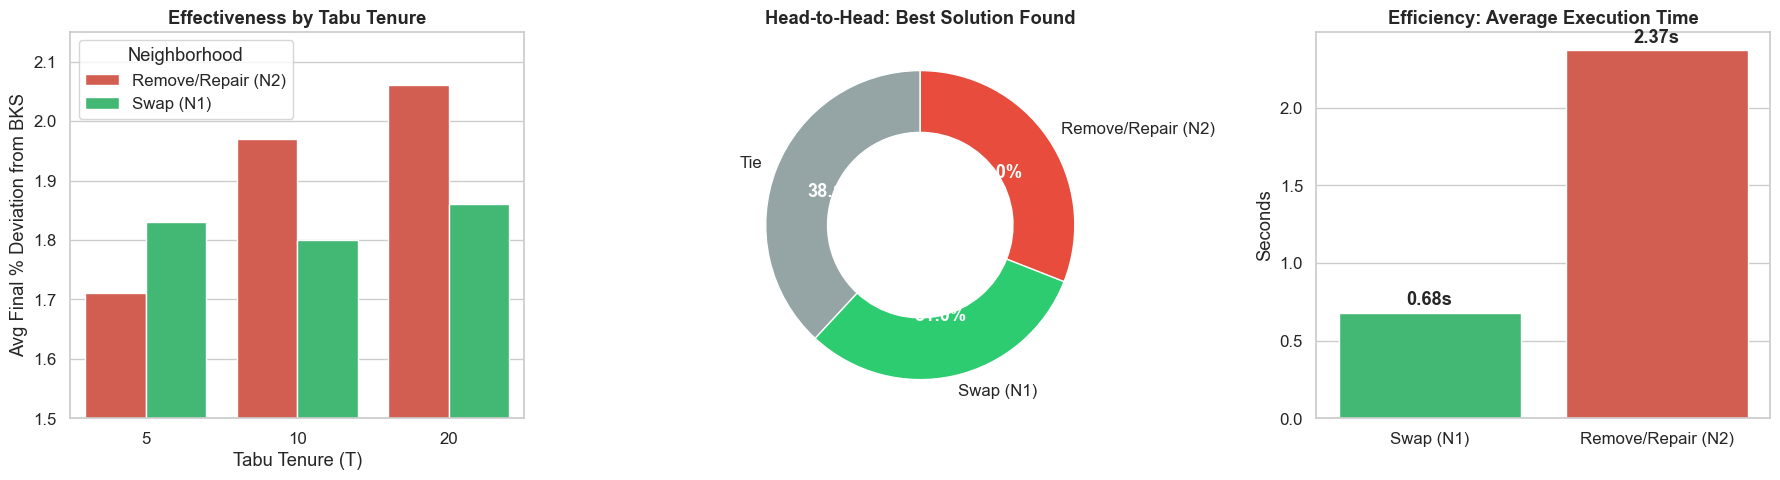

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data from your tables
summary_data = {
    "Neighborhood": ["Remove/Repair (N2)", "Remove/Repair (N2)", "Remove/Repair (N2)", "Swap (N1)", "Swap (N1)", "Swap (N1)"],
    "Tabu_Tenure": [5, 10, 20, 5, 10, 20],
    "Avg_Final_Dev": [1.71, 1.97, 2.06, 1.83, 1.80, 1.86],
    "Avg_Time_s": [2.72, 2.45, 1.95, 0.70, 0.67, 0.69]
}
df_summary = pd.DataFrame(summary_data)

win_counts = [16, 13, 13]
win_labels = ["Tie", "Swap (N1)", "Remove/Repair (N2)"]
win_colors = ["#95a5a6", "#2ecc71", "#e74c3c"]

# 2. Setup the figure
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Parameter Sensitivity (Effectiveness) ---
sns.barplot(data=df_summary, x="Tabu_Tenure", y="Avg_Final_Dev", hue="Neighborhood", ax=axes[0], palette=["#e74c3c", "#2ecc71"])
axes[0].set_title("Effectiveness by Tabu Tenure", fontweight="bold")
axes[0].set_xlabel("Tabu Tenure (T)")
axes[0].set_ylabel("Avg Final % Deviation from BKS")
axes[0].set_ylim(1.5, 2.15) # Zoom in to show the difference clearly

# --- Plot 2: Head-to-Head Win Rate ---
wedges, texts, autotexts = axes[1].pie(win_counts, labels=win_labels, colors=win_colors, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.4, edgecolor='w'))
axes[1].set_title("Head-to-Head: Best Solution Found", fontweight="bold")
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# --- Plot 3: Efficiency (Speed) ---
avg_times = [0.68, 2.37]
sns.barplot(x=["Swap (N1)", "Remove/Repair (N2)"], y=avg_times, ax=axes[2], palette=["#2ecc71", "#e74c3c"])
axes[2].set_title("Efficiency: Average Execution Time", fontweight="bold")
axes[2].set_ylabel("Seconds")
for i, v in enumerate(avg_times):
    axes[2].text(i, v + 0.05, f"{v}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()